This code calculates the electric field components of LSM modes in a dielectric-lined rectangular waveguide. It follows the approach of Xiao L. et. al., 2001, Phys. Rev. E 65 016505.

It also calculates the dispersion curves for a given LSM mode.

I plan to extend this to LSE modes too.

In [1]:
#imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
from scipy.constants import pi, epsilon_0, c
from scipy.optimize import brentq


Input parameters

In [2]:
# box dimensions
w = 23e-3   # guide width in x   [m]
b = 5.0e-3   # guide height in y  [m]
a = 3.0e-3     # height of the air region (dielectric starts at y=a) [m]
eps_r = 10        # relative permittivity of the slab


f_min, f_max, n_f = 10e9, 15e9, 100 #8GHz -> 15GHz, 300 points calc'ed
# -------------------------------------------------------------

c = c
d = b - a

### Dispersion Curves
Geometry (as in the paper): 
$$
\begin{aligned}
&(a)\quad 0 < x < w \\
&(b)\quad 0 < y < a \\
&(c)\quad a < y < b
\end{aligned}
$$
$(a)$ corresponds to the width of the slab without a dielectric on the sides, $(b)$ corresponds to the vacuum region, $(c)$ corresponds to the dielectric with $\epsilon_r$.

#### Equations in paper
I assigned a substitute variable $s$ to $\sqrt{s}=k_y^{(0)}$, where $k_y^{(1)}=\sqrt{s+(\epsilon_r-1)k^2}$. To make sure the dispersion relation is always real for both sides of $s=0$, divide the dispersion relation by $k_y^{(0)}$ and substitute in $s$. Then, pick limits of $s$ to search for. 

#### Limits of $s$
Consider $k_y^{(0)}$ and $k_y^{(1)}$. 

Without substituion,
$$
\begin{aligned}
k_y^{(0)^2}=k^2-\left(\frac{m\pi}{w}\right)^2-\beta_{mn}^2 \\
k_y^{(1)^2}=\epsilon_r{k^2}-\left(\frac{m\pi}{w}\right)^2-\beta_{mn}^2
\end{aligned}
$$

In $s$ substitution, $\sqrt{s}=k_y^{(0)}$, where $k_y^{(1)}=\sqrt{s+(\epsilon_r-1)k^2}$.

**Lower limit of s:**
By default $k_y^{(1)^2}>0$, as the field can't decay in both regions or else it won't hit the walls of the waveguide at all (no mode). Therefore,
$$
s=-\left(\epsilon_r-1\right)k^2.
$$    

**Upper limit of s:**
From the original expression for $k_y^{(0)^2}$, 
$$
\begin{aligned}
s = k^2 - \left(\frac{m\pi}{w}\right)^2 - \beta_{mn}^2, \\
\implies \beta_{mn}^2=k^2-\left(\frac{m\pi}{w}\right)^2-s,
\end{aligned}
$$
and we need $\beta_{mn}$ to be real as the propagation term in $\vec{z}$, $\textrm{exp}\left(-j\beta_{mn}z\right)$, will not be a travelling wave otherwise. Therefore I set $\beta_{mn}$ to 0.

#### Calculating $\beta_{mn}$ for different frequencies
I used
$$
\beta_{mn} = \sqrt(k^2-\left(\frac{m\pi}{w}\right)^2-s_n),
$$
where $n$ denotes the number of frequencies used in an array.

#### How code works
Uses the above principles. 



LSM11 cutoff = 10.405 GHz
LSM21 cutoff = 11.183 GHz
f range: 9.89 - 15.00 GHz
saved dispersion.png


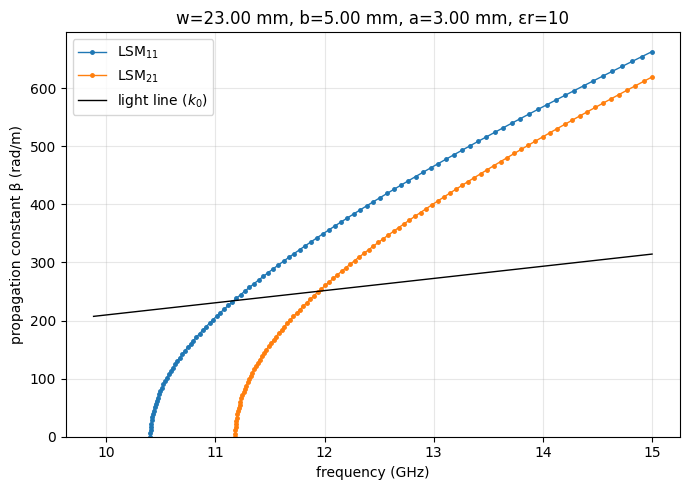

In [ ]:
def _sqrt(q):
    return np.sqrt(complex(q))


def lsm(s, k):
    """
    Eq. (4a) divided by ky0 so it stays real when ky0 is imaginary:
    ky1 sin(ky1 d) * sin(ky0 a)/ky0 - eps_r cos(ky0 a) cos(ky1 d) = 0
    """
    ky0 = _sqrt(s)
    ky1 = _sqrt(s + (eps_r - 1) * k**2)
    sinc0 = np.sin(ky0 * a) / ky0 if abs(ky0) > 1e-12 else a
    val = ky1 * np.sin(ky1 * d) * sinc0 - eps_r * np.cos(ky0 * a) * np.cos(ky1 * d)
    return val.real


def lse(s, k):
    """
    LSE relation  ky0 cot(ky0 a) = -ky1 cot(ky1 d), written pole-free and
    divided by ky0*ky1 so it stays real:
    cos(ky1 d) sin(ky0 a)/ky0 + cos(ky0 a) sin(ky1 d)/ky1 = 0
    (check against the paper's Eq. 4b)
       
    """
    ky0 = _sqrt(s)
    ky1 = _sqrt(s + (eps_r - 1) * k**2)
    sinc0 = np.sin(ky0 * a) / ky0 if abs(ky0) > 1e-12 else a
    sinc1 = np.sin(ky1 * d) / ky1 if abs(ky1) > 1e-12 else d
    val = np.cos(ky1 * d) * sinc0 + np.cos(ky0 * a) * sinc1
    return val.real


def roots_in_s(func, k, n_grid=4000):
    """All roots s = ky0^2, sorted ascending (= descending beta = n = 1, 2, ...)."""
    s_lo = -(eps_r - 1) * k**2 * (1 - 1e-9)   # beta at its max (field all in dielectric)
    s_hi = k**2                                # beta = 0 for m = 0
    grid = np.linspace(s_lo, s_hi, n_grid)
    vals = np.array([func(s, k) for s in grid])
    out = []
    for i in range(n_grid - 1):
        if vals[i] == 0:
            out.append(grid[i])
        elif vals[i] * vals[i + 1] < 0:
            out.append(brentq(func, grid[i], grid[i + 1], args=(k,)))
    return out


def cutoff(func, m, n, n_grid=4000):
    """
    Cutoff frequency of mode (m, n).

    At cutoff beta = 0, so from Eq. (3):  s = ky0^2 = k^2 - (m pi / w)^2.
    Putting that s into the dispersion relation leaves an equation in f only:
        G(f) = F(k^2 - (m pi/w)^2, k) = 0
    The n-th sign change of G as f increases is the cutoff of mode (m, n).
    """
    kx2 = (m * np.pi / w) ** 2
    G = lambda f: func((2*np.pi*f/c)**2 - kx2, 2*np.pi*f/c)

    # Lowest possible cutoff: ky1 must be real, i.e. eps_r k^2 >= kx^2.
    # (For m = 0 this is 0, so start slightly above it.)
    f_lo = c * np.sqrt(kx2) / (2*np.pi*np.sqrt(eps_r)) * (1 + 1e-9) + 1e6
    # Generous upper search limit: well above where n half-waves fit in the air region.
    f_hi = c / 2 * np.sqrt((m/w)**2 + (n/min(a, b - a))**2) * 3 + 1e9

    grid = np.linspace(f_lo, f_hi, n_grid)
    vals = np.array([G(f) for f in grid])
    found = 0
    for i in range(n_grid - 1):
        if vals[i] * vals[i + 1] < 0:
            found += 1
            if found == n:
                return brentq(G, grid[i], grid[i + 1])
    raise ValueError(f"no cutoff found for mode ({m},{n})")


def beta_curve(func, m, n, f_c, f_max):
    """
    beta(f) for mode (m, n), sampled from its own cutoff f_c up to f_max.

    Starting exactly at f_c puts a point at beta=0. Points are packed
    more densely near cutoff, where beta=sqrt(f-f_c) rises steeply
    """
    t = np.linspace(0, 1, n_f)
    freqs = f_c + (f_max - f_c) * t**2      # quadratic spacing
    betas = np.full(n_f, np.nan)
    betas[0] = 0.0                           
    kx2 = (m * np.pi / w) ** 2
    for i, f in enumerate(freqs[1:], start=1):
        k = 2 * np.pi * f / c
        s_roots = roots_in_s(func, k)
        if len(s_roots) >= n:
            beta2 = k**2 - kx2 - s_roots[n - 1]
            if beta2 > 0:
                betas[i] = np.sqrt(beta2)
    return freqs, betas


if __name__ == "__main__":

    # name modes 
    modes = [("LSM", lsm, 1, 1), ("LSM", lsm, 2, 1)]
 
    # define frequency range
    cutoffs = {}

    for name, func, m, n in modes:
        cutoffs[(name, m, n)] = cutoff(func, m, n)
        print(f"{name}{m}{n} cutoff = {cutoffs[(name, m, n)]/1e9:.3f} GHz")

    f_min = 0.95 * min(cutoffs.values())            # just below the first mode

    # make it easier to read
    print(f"f range: {f_min/1e9:.2f} - {f_max/1e9:.2f} GHz")
 
    plt.figure(figsize=(7, 5))
    for name, func, m, n in modes:
        f, bt = beta_curve(func, m, n, cutoffs[(name, m, n)], f_max)
        plt.plot(f / 1e9, bt, marker="o", ms=2.5, lw=1, label=f"{name}$_{{{m}{n}}}$")
 
    f = np.linspace(f_min, f_max, 100)
    plt.plot(f / 1e9, 2 * np.pi * f / c, "k", lw=1, label="light line ($k_0$)")
 
    plt.xlabel("frequency (GHz)")
    plt.ylabel("propagation constant β (rad/m)")
    plt.title(f"w={w*1e3:.2f} mm, b={b*1e3:.2f} mm, a={a*1e3:.2f} mm, εr={eps_r}")
    plt.ylim(bottom=0)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig("dispersion.png", dpi=150)
    print("saved dispersion.png")
 


## Field components

In [ ]:
# --- Field components for the LSM_mn mode (Xiao, Gai & Sun 2001, Eqs. (3), (6), (7)) ---

# pick the mode, then choose the operating frequency: either the frequency at
# which this mode's dispersion curve crosses the light line (beta = k), which
# is the natural synchronous-acceleration operating point for an
# ultrarelativistic beam, or a frequency of your own choosing.
m, n = 1, 1

use_light_line_frequency = True   # False -> use user_frequency instead
user_frequency = None             # Hz, only used when use_light_line_frequency is False


def find_light_line_crossing(func, m, f_lo=f_min, f_hi=f_max, n_grid=20000):
    """
    Frequency at which mode m1's dispersion curve crosses the light line
    (beta = k). At that point ky0^2 = k^2 - kx^2 - beta^2 = -kx^2 for any f,
    so this fixes s = -kx^2 and searches for the f at which the dispersion
    relation func(s, k) = 0 is satisfied.
    """
    kx2 = (m * np.pi / w) ** 2
    s_sync = -kx2
    k_grid = np.linspace(2 * np.pi * f_lo / c, 2 * np.pi * f_hi / c, n_grid)
    vals = np.array([func(s_sync, k) for k in k_grid])
    for i in range(n_grid - 1):
        if vals[i] * vals[i + 1] < 0:
            k_root = brentq(lambda k: func(s_sync, k), k_grid[i], k_grid[i + 1])
            return k_root * c / (2 * np.pi)
    raise ValueError(f"no light-line crossing found for mode m={m} in [{f_lo/1e9:.2f}, {f_hi/1e9:.2f}] GHz")


if use_light_line_frequency:
    frequency = find_light_line_crossing(lsm, m)
    print(f"LSM{m}{n} crosses the light line at f = {frequency/1e9:.4f} GHz")
else:
    if user_frequency is None:
        raise ValueError("set user_frequency (Hz) when use_light_line_frequency is False")
    frequency = user_frequency

# sanity check: this dispersion solver (roots_in_s / beta_curve, defined
# above) and the mode-continuity assumption it relies on (n-th smallest s
# root = n-th mode branch) were only validated over f_min-f_max; well
# outside that band the wrong branch can silently get picked up, so refuse
# rather than return a number that looks plausible but may not be
if not (f_min <= frequency <= 3 * f_max):
    raise ValueError(
        f"f = {frequency/1e9:.3f} GHz is far outside the range this notebook's "
        f"dispersion solver was set up for ({f_min/1e9:.2f}-{f_max/1e9:.2f} GHz). "
        f"Double-check the value (e.g. 105e9 = 105 GHz, not 10.5 GHz) - if it's "
        f"really intended, results here are not reliable that far from cutoff."
    )

k = 2 * np.pi * frequency / c
omega = 2 * np.pi * frequency

# get beta_mn by reusing the dispersion-curve calculation from the cells
# above (cutoff + beta_curve) instead of re-deriving it here
f_c = cutoff(lsm, m, n)
if frequency < f_c:
    raise ValueError(f"f = {frequency/1e9:.3f} GHz is below the LSM{m}{n} cutoff "
                      f"({f_c/1e9:.3f} GHz) - mode does not propagate there")

freqs_curve, betas_curve = beta_curve(lsm, m, n, f_c, max(f_max, frequency))
valid = ~np.isnan(betas_curve)
beta_mn = np.interp(frequency, freqs_curve[valid], betas_curve[valid])
print(f"LSM{m}{n}: beta = {beta_mn:.2f} rad/m at f = {frequency/1e9:.2f} GHz")

A_mn = 1.0   # arbitrary normalisation constant


def calculate_k_mn(m, beta_mn, f):
    """ky0, ky1 and kc for the given m and beta (Eq. 3)."""
    k = 2 * np.pi * f / c
    ky0 = _sqrt(k**2 - (m * np.pi / w) ** 2 - beta_mn**2)
    ky1 = _sqrt(eps_r * k**2 - (m * np.pi / w) ** 2 - beta_mn**2)
    kcmn = np.sqrt((m * np.pi / w) ** 2 + beta_mn**2)
    return ky0, ky1, kcmn


def calculate_B_mn(m, beta_mn, f):
    """
    B_mn/A_mn from the field-continuity conditions Eq. (7a)/(7b). The two
    are equivalent (their ratio is the dispersion relation, Eq. 4a), but
    whichever denominator is closer to zero is numerically unstable, so use
    whichever of the two has the larger denominator.
    """
    ky0, ky1, kcmn = calculate_k_mn(m, beta_mn, f)
    d = b - a

    denom_7a = ky1 * np.sin(ky1 * d)                 # Eq. (7a)
    denom_7b = eps_r * np.cos(ky1 * d)                # Eq. (7b)

    if abs(denom_7a) >= abs(denom_7b):
        return A_mn * (ky0 * np.cos(ky0 * a)) / denom_7a
    else:
        return A_mn * np.sin(ky0 * a) / denom_7b


def get_field_components(m, beta_mn, f, x, y):
    """
    Electric and magnetic field components of the LSM_mn mode (Eq. 6) at
    transverse position (x, y); x, y may be arrays (e.g. from np.meshgrid).
    The z-dependence exp(-j*beta*z) is added separately by add_z_dependence.
    """
    ky0, ky1, kcmn = calculate_k_mn(m, beta_mn, f)
    B_mn = calculate_B_mn(m, beta_mn, f)
    omega = 2 * np.pi * f
    kx = m * np.pi / w

    region0 = y < a
    phase_s = np.sin(kx * (x + w / 2))
    phase_c = np.cos(kx * (x + w / 2))

    E_x = np.where(region0,
                   A_mn * kx * ky0 * phase_c * np.cos(ky0 * y),
                   B_mn * kx * ky1 * phase_c * np.sin(ky1 * (b - y)))
    E_y = np.where(region0,
                   A_mn * kcmn**2 * phase_s * np.sin(ky0 * y),
                   B_mn * kcmn**2 * phase_s * np.cos(ky1 * (b - y)))
    E_z = np.where(region0,
                   A_mn * (-1j * beta_mn) * ky0 * phase_s * np.cos(ky0 * y),
                   B_mn * (-1j * beta_mn) * ky1 * phase_s * np.sin(ky1 * (b - y)))

    H_x = np.where(region0,
                   -A_mn * omega * epsilon_0 * beta_mn * phase_s * np.sin(ky0 * y),
                   -B_mn * omega * epsilon_0 * eps_r * beta_mn * phase_s * np.cos(ky1 * (b - y)))
    H_y = np.zeros_like(E_x)
    H_z = np.where(region0,
                   A_mn * (1j * omega * epsilon_0) * kx * phase_c * np.sin(ky0 * y),
                   B_mn * (1j * omega * epsilon_0 * eps_r) * kx * phase_c * np.cos(ky1 * (b - y)))

    return E_x, E_y, E_z, H_x, H_y, H_z


def add_z_dependence(fields, beta_mn, z):
    """Multiply each field component by the exp(-j*beta*z) travelling-wave factor."""
    z_dependence = np.exp(-1j * beta_mn * z)
    return [field * z_dependence for field in fields]


In [ ]:
# 3x2 plot of the six field components over the transverse (x, y) plane at z = 0
n_x, n_y = 200, 200
x_grid = np.linspace(-w / 2, w / 2, n_x)
y_grid = np.linspace(0, b, n_y)
X, Y = np.meshgrid(x_grid, y_grid)

fields = get_field_components(m, beta_mn, frequency, X, Y)
field_names = ["E_x", "E_y", "E_z", "H_x", "H_y", "H_z"]

fig, axes = plt.subplots(3, 2, figsize=(10, 12), sharex=True, sharey=True)
for ax, name, field in zip(axes.flat, field_names, fields):
    pcm = ax.pcolormesh(X * 1e3, Y * 1e3, np.real(field), shading="auto", cmap="RdBu_r")
    ax.axhline(a * 1e3, color="k", lw=0.8, ls="--")  # dielectric interface
    ax.set_title(name)
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    fig.colorbar(pcm, ax=ax)

fig.suptitle(f"LSM$_{{{m}{n}}}$ field components, f = {frequency/1e9:.2f} GHz, "
             f"beta = {beta_mn:.1f} rad/m")
plt.tight_layout()
plt.savefig("field_components.png", dpi=150)
print("saved field_components.png")


In [ ]:
# Normalized longitudinal electric field E_z(x, y), 3D surface (cf. Fig. 4 of the paper)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

E_z = fields[2]
E_z_norm = np.abs(E_z) / np.max(np.abs(E_z))

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(projection="3d")
ax.plot_surface(X * 1e3, Y * 1e3, E_z_norm, cmap="viridis", linewidth=0, antialiased=True)
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_zlabel("normalized |E_z|")
ax.set_title(f"LSM$_{{{m}{n}}}$ normalized longitudinal E-field, f = {frequency/1e9:.2f} GHz")
plt.tight_layout()
plt.savefig("Ez_3d.png", dpi=150)
print("saved Ez_3d.png")


In [ ]:
# Effect of the z-dependence exp(-j*beta*z): it is a pure travelling-wave phase
# factor, so it leaves |E_z| unchanged and just rotates the complex phasor;
# only the physical (real) part oscillates as the wave propagates along z.
z_vals = np.linspace(0, 4 * np.pi / beta_mn, 400)   # a couple of guide wavelengths
x0, y0 = 0.0, a / 2   # an arbitrary point in the vacuum region

E_z_point = get_field_components(m, beta_mn, frequency, np.array(x0), np.array(y0))[2]
E_z_z = add_z_dependence([np.full_like(z_vals, E_z_point, dtype=complex)], beta_mn, z_vals)[0]

plt.figure(figsize=(7, 4))
plt.plot(z_vals * 1e3, np.real(E_z_z), label="Re(E_z)")
plt.plot(z_vals * 1e3, np.abs(E_z_z), "k--", label="|E_z|")
plt.xlabel("z (mm)")
plt.ylabel("E_z (a.u.)")
plt.title(f"Travelling wave along z at (x,y) = ({x0*1e3:.1f}, {y0*1e3:.1f}) mm")
plt.legend()
plt.tight_layout()
plt.savefig("Ez_vs_z.png", dpi=150)
print("saved Ez_vs_z.png")
